In [1]:
# importing the necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from tensorflow.keras.models import Sequential
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving airbnb2.csv to airbnb2 (1).csv


In [3]:
df = pd.read_csv("airbnb2.csv")
df.head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


In [4]:
# CHECKING FOR MISSING VALUES
df.isnull().sum()

,0
id,0
log_price,0
property_type,0
room_type,0
amenities,0
accommodates,0
bathrooms,6
bed_type,0
cancellation_policy,0
cleaning_fee,0


In [5]:
#DROPPING MISSING VALUES
df.dropna(axis = 0, inplace = True, subset = ['first_review','host_response_rate','last_review','neighbourhood','host_has_profile_pic','host_identity_verified','host_since','thumbnail_url','zipcode'])

In [6]:
#REPLACING MISSING VALUES WITH MEAN
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].mean())
df['review_scores_rating'] = df['review_scores_rating'].fillna(df['review_scores_rating'].mean())
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].mean())
df['beds'] = df['beds'].fillna(df['beds'].mean())

In [7]:
df_train, df_test  = train_test_split(df, test_size=0.2, random_state = 42)

In [8]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 806 entries, 60 to 202
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      806 non-null    int64  
 1   log_price               806 non-null    float64
 2   property_type           806 non-null    object 
 3   room_type               806 non-null    object 
 4   amenities               806 non-null    object 
 5   accommodates            806 non-null    int64  
 6   bathrooms               806 non-null    float64
 7   bed_type                806 non-null    object 
 8   cancellation_policy     806 non-null    object 
 9   cleaning_fee            806 non-null    bool   
 10  city                    806 non-null    object 
 11  description             806 non-null    object 
 12  first_review            806 non-null    object 
 13  host_has_profile_pic    806 non-null    object 
 14  host_identity_verified  806 non-null    object

In [9]:
df_train.describe()

,id,log_price,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
count,8.060000e+02,806.000000,806.000000,806.000000,806.000000,806.000000,806.000000,806.000000,806.000000,806.000000
mean,1.122904e+07,4.751109,3.168734,1.200264,38.742059,-91.486282,32.972705,94.449826,1.247189,1.784119
std,6.222406e+06,0.662254,2.087244,0.466599,3.028517,21.685440,44.704182,6.701798,0.829432,1.328351
min,1.206800e+04,2.944439,1.000000,0.000000,33.722757,-122.508521,1.000000,20.000000,0.000000,1.000000
25%,5.691018e+06,4.317488,2.000000,1.000000,34.190150,-118.344410,5.250000,92.000000,1.000000,1.000000
50%,1.242135e+07,4.691348,2.000000,1.000000,40.684712,-74.000822,15.000000,96.000000,1.000000,1.000000
75%,1.665650e+07,5.164786,4.000000,1.000000,40.758575,-73.949644,43.000000,99.000000,1.000000,2.000000
max,2.118810e+07,7.277939,16.000000,5.500000,42.382883,-71.049672,318.000000,100.000000,7.000000,16.000000


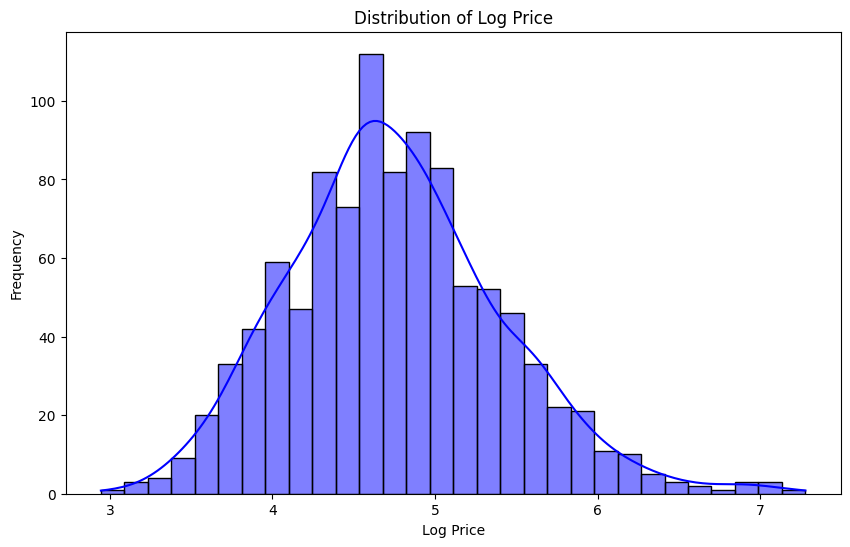

In [10]:
# distribution of price across the dataset

#histogram with kde for `log_price`
#KDE is the lining above the histogram indicates density estimate for better analysis
plt.figure(figsize=(10, 6))
sns.histplot(df['log_price'], kde=True, bins=30, color='blue')
plt.title('Distribution of Log Price')
plt.xlabel('Log Price')
plt.ylabel('Frequency')
plt.show()

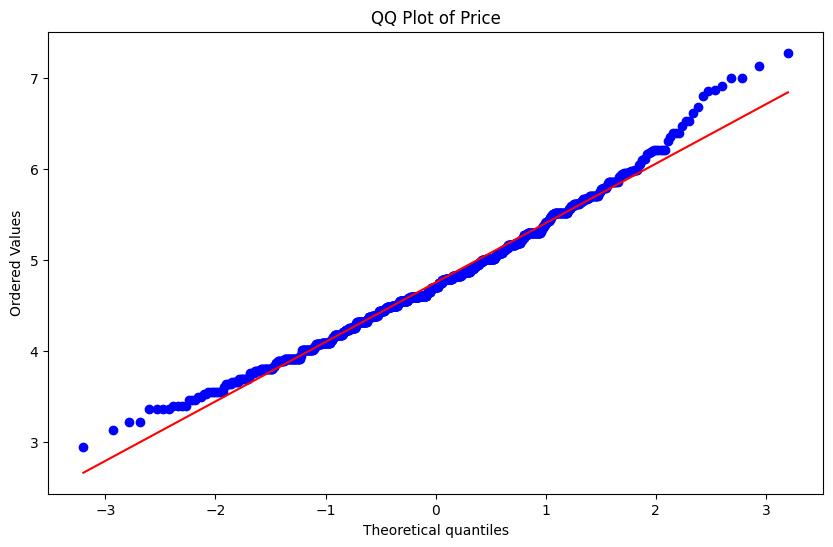

In [11]:
#qqplot of the price
plt.figure(figsize=(10, 6))
stats.probplot(df['log_price'], dist="norm", plot=plt)
plt.title('QQ Plot of Price')
plt.show()

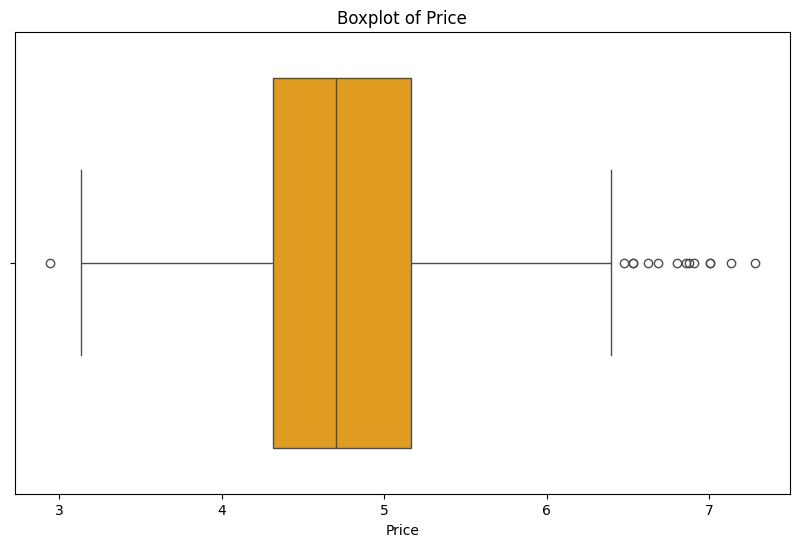

In [12]:
# check for outliers in the dataset (boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['log_price'], color='orange')
plt.title('Boxplot of Price')
plt.xlabel('Price')
plt.show()

In [13]:
# Calculate Q1, Q3, and IQR
Q1 = df['log_price'].quantile(0.25)
Q3 = df['log_price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['log_price'] < lower_bound) | (df['log_price'] > upper_bound)]
print("Number of outliers: ", len(outliers))

Number of outliers:  14


In [14]:
#  Handle outliers
df_cleaned = df[(df['log_price'] >= lower_bound) & (df['log_price'] <= upper_bound)]
print(df_cleaned.shape)

(994, 29)


In [15]:
# Handle the categorical values
# Handling categorical values with one-hot encoding
categorical_columns = ['property_type', 'room_type', 'bed_type', 'cancellation_policy', 'city', 'neighbourhood']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df_cleaned, columns=categorical_columns, drop_first=True)

print("Categorical values handled with one-hot encoding.")
print("Updated dataset shape:", df_encoded.shape)


Categorical values handled with one-hot encoding.
Updated dataset shape: (994, 321)


In [16]:
# Normalize the numerical values
# Columns to normalize
numerical_columns = ['log_price', 'accommodates', 'bathrooms', 'latitude', 'longitude',
                     'number_of_reviews', 'review_scores_rating', 'bedrooms', 'beds']

# Initialize Min-Max Scaler
scaler = MinMaxScaler()

# Apply scaling
df_encoded[numerical_columns] = scaler.fit_transform(df_encoded[numerical_columns])

print("Numerical values normalized.")
print(df_encoded[numerical_columns].describe())

Numerical values normalized.
        log_price  accommodates   bathrooms    latitude   longitude  \
count  994.000000    994.000000  994.000000  994.000000  994.000000   
mean     0.488303      0.140711    0.340015    0.582463    0.611921   
std      0.187793      0.132049    0.126752    0.345513    0.418667   
min      0.000000      0.000000    0.000000    0.000000    0.000000   
25%      0.362415      0.066667    0.285714    0.055220    0.080981   
50%      0.477046      0.066667    0.285714    0.803898    0.942657   
75%      0.612868      0.200000    0.285714    0.812095    0.943649   
max      1.000000      1.000000    1.000000    1.000000    1.000000   

       number_of_reviews  review_scores_rating    bedrooms        beds  
count         994.000000            994.000000  994.000000  994.000000  
mean            0.082248              0.928838    0.173216    0.048357  
std             0.115829              0.084763    0.111983    0.083131  
min             0.000000              0

In [17]:
# to remove unwanted columns using feature importance

#dropping 'object' columns
df_encoded1 = df_encoded.drop(columns=["amenities", "description", "name", "thumbnail_url"], axis=1)

#dropping 'neighbourhood_' columns
df_encoded1 = df_encoded1.loc[:, ~df_encoded1.columns.str.startswith('neighbourhood_')]

#handling date columns
date_columns = ["first_review", "host_since", "last_review"]
for column in date_columns:
    df_encoded1[column] = pd.to_datetime(df_encoded1[column])
    df_encoded1[f'{column}_Year'] = df_encoded1[column].dt.year
    df_encoded1[f'{column}_Month'] = df_encoded1[column].dt.month
    df_encoded1[f'{column}_Day'] = df_encoded1[column].dt.day
    df_encoded1 = df_encoded1.drop(column, axis=1)  # Drop the original date column

#converting string to float64
df_encoded1["host_response_rate"] = df_encoded1["host_response_rate"].str.replace('%', '').astype(float)

#replacing 't' and 'f' with bool vlaues
columns_to_transform = ['host_has_profile_pic', 'host_identity_verified', 'instant_bookable']
df_encoded1[columns_to_transform] = df_encoded1[columns_to_transform].replace({'t': True, 'f': False})

#seperating features and target variable
X = df_encoded1.drop(columns=["log_price"], axis = 1)
y = df_encoded1["log_price"]

#taining random forest regressor
model = RandomForestRegressor()
model.fit(X, y)

#feature importance
importances = model.feature_importances_

#df for better visualization of feature importance
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

threshold = 0.01
important_features = feature_importance_df[feature_importance_df["Importance"] >= threshold]["Feature"]

#remove unwanted columns
df_selected = X[important_features]

<ipython-input-17-236cd2552aec>:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encoded1[columns_to_transform] = df_encoded1[columns_to_transform].replace({'t': True, 'f': False})


# Model training

In [18]:
# use linear regression to train the model
X_train, X_test, y_train, y_test = train_test_split(df_selected, y, test_size=0.2, random_state=42)

linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

LinearRegression()

# Model Evaluation

In [19]:
# evaluate the model on the testing dataset

# Evaluate Random Forest model
y_pred_rf = model.predict(X)

mse_rf = mean_squared_error(y, y_pred_rf)
mae_rf = mean_absolute_error(y, y_pred_rf)
r2_rf = r2_score(y, y_pred_rf)

# Print evaluation metrics for Random Forest
print("Random Forest Regressor Evaluation:")
print(f"Mean Squared Error (MSE): {mse_rf}")
print(f"Mean Absolute Error (MAE): {mae_rf}")
print(f"R-squared (R²): {r2_rf}")

Random Forest Regressor Evaluation:
Mean Squared Error (MSE): 0.001662266708873852
Mean Absolute Error (MAE): 0.03180638169238048
R-squared (R²): 0.9528177515875577


In [20]:
#test on an instance
instance = X_test.iloc[0].values.reshape(1, -1)
predicted_value = linear_reg.predict(instance)

print(f"predicted value: {predicted_value[0]}")
print(f"actual value: {y_test.iloc[0]}")

predicted value: 0.48372775178807004
actual value: 0.43489521778835916


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [21]:

#Make predictions with the trained Linear Regression model
lr_pred = linear_reg.predict(X_test)

# Evaluate the Linear Regression model
mse_lr = mean_squared_error(y_test, lr_pred)
mae_lr = mean_absolute_error(y_test, lr_pred)
r2_lr = r2_score(y_test, lr_pred)

print("Linear Regression Evaluation:")
print(f"Mean Squared Error (MSE): {mse_lr:.4f}")
print(f"Mean Absolute Error (MAE): {mae_lr:.4f}")
print(f"R-squared (R²): {r2_lr:.4f}")

Linear Regression Evaluation:
Mean Squared Error (MSE): 0.0173
Mean Absolute Error (MAE): 0.1022
R-squared (R²): 0.5167


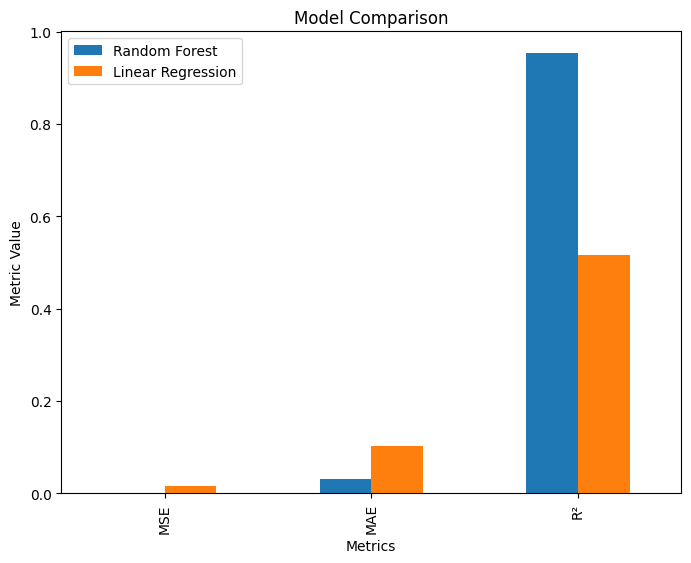

In [22]:
metrics = ['MSE', 'MAE', 'R²']
rf_metrics = [mse_rf, mae_rf, r2_rf]
lr_metrics = [mse_lr, mae_lr, r2_lr]

evaluation_df = pd.DataFrame({
    'Metrics': metrics,
    'Random Forest': rf_metrics,
    'Linear Regression': lr_metrics
})

# Plotting the comparison
evaluation_df.set_index('Metrics').plot(kind='bar', figsize=(8, 6))
plt.title('Model Comparison')
plt.ylabel('Metric Value')
plt.show()

In [27]:
# Hyperparameter Tuning :

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')     # To ignore the unecessary warnings being displayed to the console

# Defining Hyperparameter Grid for Ridge :
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

# Grid search with cross-validation :
ridge = Ridge()
grid_search = GridSearchCV(ridge, param_grid, scoring='neg_mean_squared_error', cv=5)
grid_search.fit(X_train, y_train)

# Best Hyperparameters :
best_alpha = grid_search.best_params_['alpha']
best_model = grid_search.best_estimator_

# Evaluating the Model Performance :
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print(f"Best alpha: {best_alpha}")
print(f"Test MSE: {mse}")


Best alpha: 0.01
Test MSE: 0.01725291280328486
